## Dynamics and gradient descent
Optimization dynamics in pytorch


In [1]:
import torch as t
import matplotlib.pyplot as plt
%matplotlib inline

device = t.device("cuda" if t.cuda.is_available() else "cpu")
device = t.device('mps') if t.backends.mps.is_available() else device

In [2]:
# Stuff for animation
import numpy as np
import matplotlib.animation as animation
from matplotlib import collections as mc
from matplotlib import rcParams, ticker, cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import HTML
rcParams['animation.html'] = 'jshtml'  # Makes the default animation an interactive video
rcParams['animation.embed_limit'] = 2**128  # Allow bigger animations
plt.style.use('seaborn-talk')  # also try 'seaborn-paper', 'fivethirtyeight'

def contour(potential, ax, center=(0,0), x_max=3, n_x=100):
    """Take a 2-d function, potential, and plot contour plot on the supplied matplotlib axis, ax.
    center gives the center and x_max the range to plot around the center.
    n_x is resolution of grid for evaluation. """
    grid = np.linspace(-x_max, x_max, n_x)
    xv, yv = np.meshgrid(grid + center[0], grid + center[1])
    x_grid = np.array([xv, yv]).reshape((2, n_x * n_x)).T
    energy = potential(x_grid)
    cs = ax.contourf(xv, yv, energy.reshape((n_x, n_x)), locator=ticker.LogLocator(), cmap=cm.PuBu_r)  # LogLocator gives log color scale
    ax.set_title("Potential energy function")
    ax.set_ylabel('$x_2$')
    ax.set_xlabel('$x_1$')

    # Add a colorbar - wow, kind of complicated
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(cs, cax=cax)


def viz_trajectories(t, f=None, n_x=100, decay=0.95, xmin=-1, xmax=1, ymin=-2, ymax=0.3):
    """t is the time series of 2-d trajectories. indices are loop, time, (x,y) location.
    n_x controls resolution, decay control trailing line decay.
    f is an optional function to plot the potential."""
    assert t.shape[2] == 2, "Dimensions should be loop, time, (x,y) location"
    ns = t.shape[1] - 1
    fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
    fig.set_size_inches(6, 6, forward=True)

    if f is not None:  # Contour plot, if f is available
        # xmin, xmax, ymin, ymax = np.min(t[:,:,0]), np.max(t[:,:,0]), np.min(t[:,:,1]), np.max(t[:,:,1])
        xv, yv = np.meshgrid(np.linspace(xmin, xmax, n_x), np.linspace(ymin, ymax, n_x))
        x_grid = np.array([xv, yv]).reshape((2, n_x * n_x)).T
        energy = f(x_grid)

        e_grid = energy.reshape((n_x, n_x))
        xs_grid = x_grid[:, 0].reshape((n_x, n_x))
        ys_grid = x_grid[:, 1].reshape((n_x, n_x))
        ax.contourf(xs_grid, ys_grid, e_grid,
                    locator=ticker.LogLocator(subs='auto'), cmap=cm.PuBu_r,  # Log color scale, 5 contours
                    zorder=0, alpha=0.7)  # zorder puts the contour plot behind other plots

    cols = []
    for ti in t:
        ls = np.array([ti[:-1], ti[1:]]).transpose((1, 0, 2))
        lc = mc.LineCollection(ls, linewidths=3, colors=(0,0,0,0))
        col = ax.add_collection(lc)
        cols.append(col)

    ax.set_title("t={}".format(0))
    ax.set_xlim(left=xmin, right=xmax)
    ax.set_ylim(bottom=ymin, top=ymax)
    ax.set_xlabel('weight')
    ax.set_ylabel('bias')

    def update_plot(i):
        for col in cols:
            col.set_color([(0,0,0, decay**(i-j)) if j <= i else (0,0,0,0) for j in range(ns)])
        ax.set_title("t={}".format(i))
        return col,

    ani = animation.FuncAnimation(fig, update_plot, frames=range(ns), interval=20, blit=True)
    plt.close()
    return ani


/var/folders/54/pj9ld3wn5fg5y9gdv7hb03nm0000gp/T/ipykernel_74922/2392659459.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-talk')  # also try 'seaborn-paper', 'fivethirtyeight'


### Data
Let's start with a synthetic nonlinear regression dataset, that we can visualize

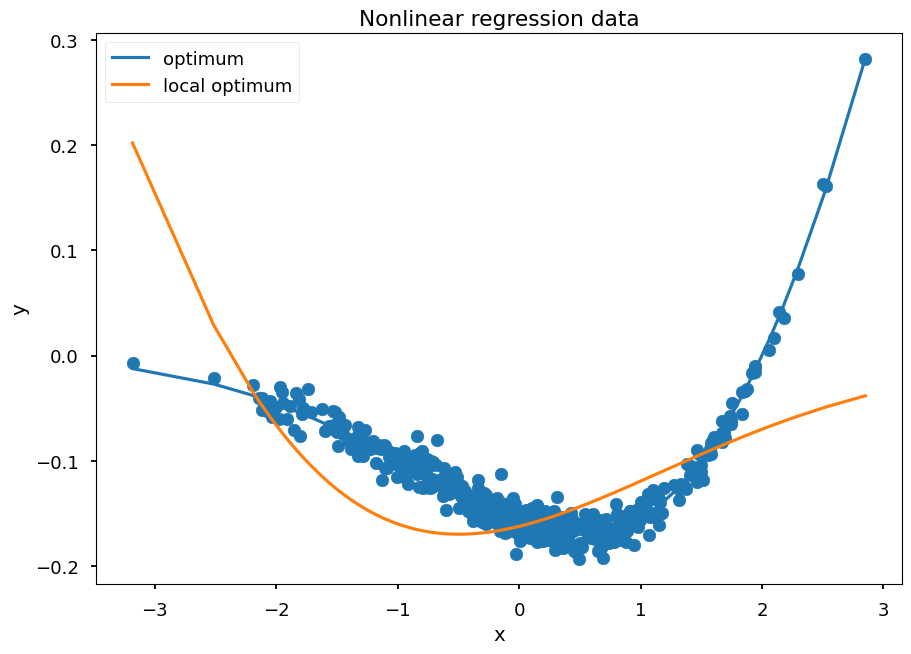

In [3]:
n_samples = 500
x = t.randn(n_samples)
w_gt = 0.5
b_gt = -1.
t.random.manual_seed(0)
y = t.nn.functional.gelu(w_gt * x + b_gt) + 0.01 * t.randn(n_samples)

# plot
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Nonlinear regression data')
y_t = t.nn.functional.gelu(w_gt * x.sort().values + b_gt)  # true solution
ax.plot(x.sort().values, y_t, label='optimum')
y_lo = t.nn.functional.gelu(-0.4 * x.sort().values - 0.95) # a local optima
ax.plot(x.sort().values, y_lo, label='local optimum')
ax.legend()


def energy(ws):
    """Loss as a function of the parameters - needed in this form for plotting"""
    ws = t.tensor(ws)
    y_hat = t.nn.functional.gelu(ws[:, [0]] * x + ws[:, [1]])
    return t.square(y_hat - y).mean(dim=1).numpy()


### Model

In [4]:
class Model(t.nn.Module):
    """A simple nonlinear model which can fit the toy data above"""
    def __init__(self):
        super().__init__()
        # manually initializing the parameters
        self.w = t.nn.Parameter(t.randn(1))
        self.b = t.nn.Parameter(t.randn(1))

    def forward(self, x):
        return t.nn.functional.gelu(self.w * x + self.b)

### Visualize training dynamics

In [20]:
# How will these hyper-parameters affect the training dynamics?
batch_size = 1  # n_samples was 500
n_epochs = 100
learning_rate = 0.03
momentum = 0.  # ????

# Seed 0 is "easy", 1 is "hard". Adam with batch size 10 and lr 0.1 kind of works on that one
# Seed 4 has init on other side
t.random.manual_seed(4)  
model = Model().to(device)

# Construct a dataloader - huge benefits for larger datasets
dataset = t.utils.data.TensorDataset(x, y)
dataloader = t.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Choose a loss function
mse_loss = t.nn.MSELoss()

# Choose an optimizer
optimizer = t.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
# optimizer = t.optim.Adam(model.parameters(), lr=learning_rate)  # ????

# track dynamics in "ws" tensor for plotting
ws = t.zeros(2, n_epochs + 1, 2)
ws[0, 0, 0] = model.w.detach().cpu().clone()
ws[0, 0, 1] = model.b.detach().cpu().clone()
# Make a star around the ground truth to draw the eye
ws[1,:, 0] = w_gt + 0.02 * t.cos(5 * np.pi / 4 * t.arange(n_epochs+1))
ws[1,:, 1] = b_gt + 0.02 * t.sin(5 * np.pi / 4 * t.arange(n_epochs+1))

# MAIN TRAINING LOOP!
for i in range(n_epochs):
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()  # zero out the gradients
        
        batch_y_hat = model(batch_x)  # forward pass
        loss = mse_loss(batch_y_hat, batch_y)  # compute loss
        
        loss.backward()  # backward pass, compute gradients
        optimizer.step()  # Update weights using optimizer

        # Store the weights for plotting
        ws[0, i+1, 0] = model.w.detach().cpu().clone()
        ws[0, i+1, 1] = model.b.detach().cpu().clone()

    if i % 20 == 0:
        print(f'Epoch {i}, loss {loss.item():.5f}')



Epoch 0, loss 0.00001
Epoch 20, loss 0.00000
Epoch 40, loss 0.00135
Epoch 60, loss 0.00040
Epoch 80, loss 0.00095


In [21]:
# Visualize the training dynamics
out = viz_trajectories(ws.numpy(), f=energy, n_x=100, decay=0.95)

In [22]:
out.save('test2.mp4', writer='ffmpeg', fps=30)

In [ ]:
out.